In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Physics parameter
nu = 0.01 / np.pi

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


In [ ]:
def generate_training_data(N_initial_condition, N_boundary_condition, N_f, device):
    # Initial condition: t = 0
    x_ic = np.random.uniform(-1, 1, (N_initial_condition, 1))
    t_ic = np.zeros((N_initial_condition, 1))
    u_ic = -np.sin(np.pi * x_ic)

    # Boundary condition: x = -1 and x = 1
    t_bc = np.random.uniform(0, 1, (N_boundary_condition, 1))

    x_bc_left = -np.ones((N_boundary_condition // 2, 1))
    x_bc_right = np.ones((N_boundary_condition // 2, 1))

    t_bc_left = t_bc[:N_boundary_condition // 2]
    t_bc_right = t_bc[N_boundary_condition // 2:]

    u_bc_left = np.zeros((N_boundary_condition // 2, 1))
    u_bc_right = np.zeros((N_boundary_condition // 2, 1))

    # Collocation points inside domain
    x_f = np.random.uniform(-1, 1, (N_f, 1))
    t_f = np.random.uniform(0, 1, (N_f, 1))

    # Convert to tensors
    data = {
        "x_ic": torch.tensor(x_ic, dtype=torch.float32).to(device),
        "t_ic": torch.tensor(t_ic, dtype=torch.float32).to(device),
        "u_ic": torch.tensor(u_ic, dtype=torch.float32).to(device),

        "x_bc_left": torch.tensor(x_bc_left, dtype=torch.float32).to(device),
        "t_bc_left": torch.tensor(t_bc_left, dtype=torch.float32).to(device),
        "u_bc_left": torch.tensor(u_bc_left, dtype=torch.float32).to(device),

        "x_bc_right": torch.tensor(x_bc_right, dtype=torch.float32).to(device),
        "t_bc_right": torch.tensor(t_bc_right, dtype=torch.float32).to(device),
        "u_bc_right": torch.tensor(u_bc_right, dtype=torch.float32).to(device),

        "x_f": torch.tensor(x_f, dtype=torch.float32).to(device),
        "t_f": torch.tensor(t_f, dtype=torch.float32).to(device),
    }

    return data

In [ ]:
class PINNSolver(nn.Module):
    def __init__(
        self,
        layers,
        nu,
        device,
        adaptive_weights=False,
        lambda_ic=1.0,
        lambda_bc=1.0,
        lambda_pde=1.0
    ):
        super(PINNSolver, self).__init__()

        self.nu = nu
        self.device = device
        self.adaptive_weights = adaptive_weights

        # Manual weights
        self.lambda_ic = lambda_ic
        self.lambda_bc = lambda_bc
        self.lambda_pde = lambda_pde

        # Network
        self.activation = nn.Tanh()
        self.linears = nn.ModuleList()

        for i in range(len(layers) - 1):
            self.linears.append(nn.Linear(layers[i], layers[i + 1]))

        self.initialize_weights()

        # Adaptive log-weights
        if self.adaptive_weights:
            self.log_lambda_ic = nn.Parameter(torch.tensor(0.0, dtype=torch.float32, device=self.device))
            self.log_lambda_bc = nn.Parameter(torch.tensor(0.0, dtype=torch.float32, device=self.device))
            self.log_lambda_pde = nn.Parameter(torch.tensor(0.0, dtype=torch.float32, device=self.device))
        else:
            self.log_lambda_ic = None
            self.log_lambda_bc = None
            self.log_lambda_pde = None

        self.to(self.device)

    def initialize_weights(self):
        for layer in self.linears:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x, t):
        inputs = torch.cat([x, t], dim=1)   # shape [N, 2]
        a = inputs

        for i in range(len(self.linears) - 1):
            a = self.linears[i](a)
            a = self.activation(a)

        output = self.linears[-1](a)
        return output

    def pde_residual(self, x, t):
        # Clone and enable gradients for PDE derivatives
        x = x.clone().detach().requires_grad_(True)
        t = t.clone().detach().requires_grad_(True)

        u = self.forward(x, t)

        u_t = torch.autograd.grad(
            u, t,
            grad_outputs=torch.ones_like(u),
            create_graph=True,
            retain_graph=True
        )[0]

        u_x = torch.autograd.grad(
            u, x,
            grad_outputs=torch.ones_like(u),
            create_graph=True,
            retain_graph=True
        )[0]

        u_xx = torch.autograd.grad(
            u_x, x,
            grad_outputs=torch.ones_like(u_x),
            create_graph=True,
            retain_graph=True
        )[0]

        f = u_t + u * u_x - self.nu * u_xx
        return f

    def compute_losses(self, data):
        mse = nn.MSELoss()

        # Initial condition loss
        u_pred_ic = self.forward(data["x_ic"], data["t_ic"])
        loss_ic = mse(u_pred_ic, data["u_ic"])

        # Boundary condition loss
        u_pred_bc_left = self.forward(data["x_bc_left"], data["t_bc_left"])
        u_pred_bc_right = self.forward(data["x_bc_right"], data["t_bc_right"])
        loss_bc = mse(u_pred_bc_left, data["u_bc_left"]) + mse(u_pred_bc_right, data["u_bc_right"])

        # PDE residual loss
        f_pred = self.pde_residual(data["x_f"], data["t_f"])
        loss_pde = mse(f_pred, torch.zeros_like(f_pred))

        return loss_ic, loss_bc, loss_pde

    def compute_total_loss(self, data):
        loss_ic, loss_bc, loss_pde = self.compute_losses(data)

        if self.adaptive_weights:
            total_loss = (
                torch.exp(-self.log_lambda_ic) * loss_ic + self.log_lambda_ic +
                torch.exp(-self.log_lambda_bc) * loss_bc + self.log_lambda_bc +
                torch.exp(-self.log_lambda_pde) * loss_pde + self.log_lambda_pde
            )
        else:
            total_loss = (
                self.lambda_ic * loss_ic +
                self.lambda_bc * loss_bc +
                self.lambda_pde * loss_pde
            )

        return total_loss, loss_ic, loss_bc, loss_pde

    def fit(self, data, epochs=2000, lr=1e-3, print_every=200):
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)

        history = {
            "total_loss": [],
            "loss_ic": [],
            "loss_bc": [],
            "loss_pde": []
        }

        if self.adaptive_weights:
            history["lambda_ic"] = []
            history["lambda_bc"] = []
            history["lambda_pde"] = []

        for epoch in range(epochs):
            self.train()
            optimizer.zero_grad()

            total_loss, loss_ic, loss_bc, loss_pde = self.compute_total_loss(data)

            total_loss.backward()
            optimizer.step()

            history["total_loss"].append(total_loss.item())
            history["loss_ic"].append(loss_ic.item())
            history["loss_bc"].append(loss_bc.item())
            history["loss_pde"].append(loss_pde.item())

            if self.adaptive_weights:
                history["lambda_ic"].append(torch.exp(-self.log_lambda_ic).item())
                history["lambda_bc"].append(torch.exp(-self.log_lambda_bc).item())
                history["lambda_pde"].append(torch.exp(-self.log_lambda_pde).item())

            if epoch % print_every == 0:
                if self.adaptive_weights:
                    print(
                        f"Epoch {epoch:5d} | Total: {total_loss.item():.6f} | "
                        f"IC: {loss_ic.item():.6f} | BC: {loss_bc.item():.6f} | PDE: {loss_pde.item():.6f} | "
                        f"λ_ic: {torch.exp(-self.log_lambda_ic).item():.4f} | "
                        f"λ_bc: {torch.exp(-self.log_lambda_bc).item():.4f} | "
                        f"λ_pde: {torch.exp(-self.log_lambda_pde).item():.4f}"
                    )
                else:
                    print(
                        f"Epoch {epoch:5d} | Total: {total_loss.item():.6f} | "
                        f"IC: {loss_ic.item():.6f} | BC: {loss_bc.item():.6f} | PDE: {loss_pde.item():.6f}"
                    )

        return history

    def predict(self, x, t):
        self.eval()

        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)
        if not torch.is_tensor(t):
            t = torch.tensor(t, dtype=torch.float32)

        x = x.to(self.device)
        t = t.to(self.device)

        with torch.no_grad():
            u_pred = self.forward(x, t)

        return u_pred.cpu().numpy()

    def plot_loss_history(self, history):
        plt.figure(figsize=(10, 6))
        plt.plot(history["total_loss"], label="Total Loss")
        plt.plot(history["loss_ic"], label="IC Loss")
        plt.plot(history["loss_bc"], label="BC Loss")
        plt.plot(history["loss_pde"], label="PDE Loss")
        plt.yscale("log")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss Curves")
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_adaptive_weights(self, history):
        if not self.adaptive_weights:
            print("Adaptive weighting is disabled for this model.")
            return

        plt.figure(figsize=(10, 6))
        plt.plot(history["lambda_ic"], label="Adaptive λ_ic")
        plt.plot(history["lambda_bc"], label="Adaptive λ_bc")
        plt.plot(history["lambda_pde"], label="Adaptive λ_pde")
        plt.xlabel("Epoch")
        plt.ylabel("Weight Value")
        plt.title("Adaptive Loss Weights Over Training")
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_solution(self, x_points=200, t_points=100):
        x_vals = np.linspace(-1, 1, x_points)
        t_vals = np.linspace(0, 1, t_points)

        X, T = np.meshgrid(x_vals, t_vals)

        x_test = torch.tensor(X.flatten()[:, None], dtype=torch.float32).to(self.device)
        t_test = torch.tensor(T.flatten()[:, None], dtype=torch.float32).to(self.device)

        self.eval()
        with torch.no_grad():
            u_pred = self.forward(x_test, t_test).cpu().numpy()

        U_pred = u_pred.reshape(T.shape)

        plt.figure(figsize=(10, 5))
        contour = plt.contourf(X, T, U_pred, levels=100, cmap="jet")
        plt.colorbar(contour, label="u(x,t)")
        plt.xlabel("x")
        plt.ylabel("t")
        plt.title("Predicted Solution from PINN")
        plt.show()

    def plot_initial_condition_comparison(self):
        x_ic_plot = np.linspace(-1, 1, 200)[:, None]
        t_ic_plot = np.zeros_like(x_ic_plot)

        x_ic_tensor = torch.tensor(x_ic_plot, dtype=torch.float32).to(self.device)
        t_ic_tensor = torch.tensor(t_ic_plot, dtype=torch.float32).to(self.device)

        self.eval()
        with torch.no_grad():
            u_ic_pred = self.forward(x_ic_tensor, t_ic_tensor).cpu().numpy()

        u_ic_true = -np.sin(np.pi * x_ic_plot)

        plt.figure(figsize=(8, 5))
        plt.plot(x_ic_plot, u_ic_true, label="True Initial Condition", linewidth=2)
        plt.plot(x_ic_plot, u_ic_pred, "--", label="PINN Prediction", linewidth=2)
        plt.xlabel("x")
        plt.ylabel("u(x,0)")
        plt.title("Initial Condition Comparison")
        plt.legend()
        plt.grid(True)
        plt.show()

## *Baseline PINN*

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch     0 | Total: 0.578503 | IC: 0.565719 | BC: 0.012625 | PDE: 0.000159
Epoch   200 | Total: 0.158059 | IC: 0.088871 | BC: 0.005622 | PDE: 0.063567
Epoch   400 | Total: 0.150227 | IC: 0.080989 | BC: 0.006143 | PDE: 0.063095
Epoch   600 | Total: 0.114450 | IC: 0.062600 | BC: 0.002780 | PDE: 0.049070
Epoch   800 | Total: 0.103024 | IC: 0.055097 | BC: 0.001535 | PDE: 0.046392
Epoch  1000 | Total: 0.094525 | IC: 0.051212 | BC: 0.000782 | PDE: 0.042530
Epoch  1200 | Total: 0.086550 | IC: 0.047724 | BC: 0.000418 | PDE: 0.038408
Epoch  1400 | Total: 0.078062 | IC: 0.044022 | BC: 0.000332 | PDE: 0.033708
Epoch  1600 | Total: 0.073196 | IC: 0.039806 | BC: 0.001735 | PDE: 0.031655
Epoch  1800 | Total: 0.052276 | IC: 0.029427 | BC: 0.000241 | PDE: 0.022609
Epoch  2000 | Total: 0.057084 | IC: 0.021338 | BC: 0.001630 | PDE: 0.034117
Epoch  2200 | Total: 0.026976 | IC: 0.012584 | BC: 0.000162 | PDE: 0.014231
Epoch  2400 | Total: 0.017330 | IC: 0.008680 | BC: 0.000078 | PDE: 0.008572
Epoch  2600 

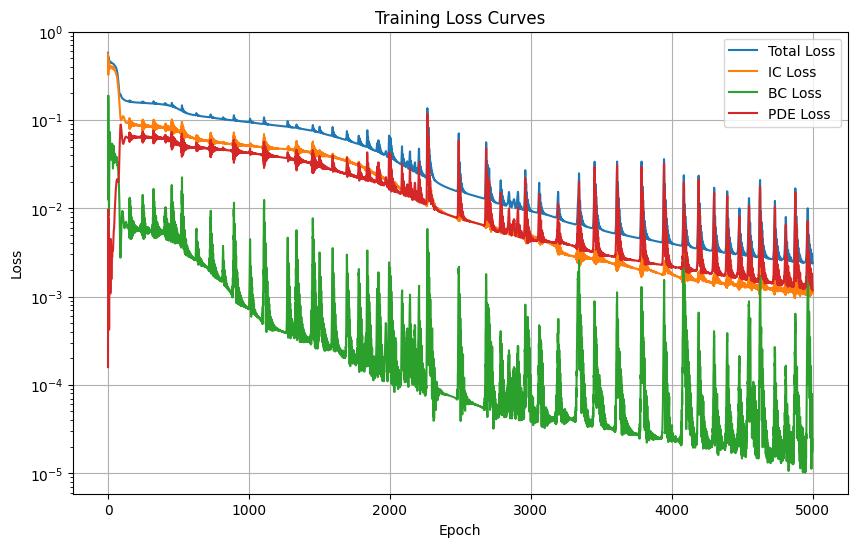

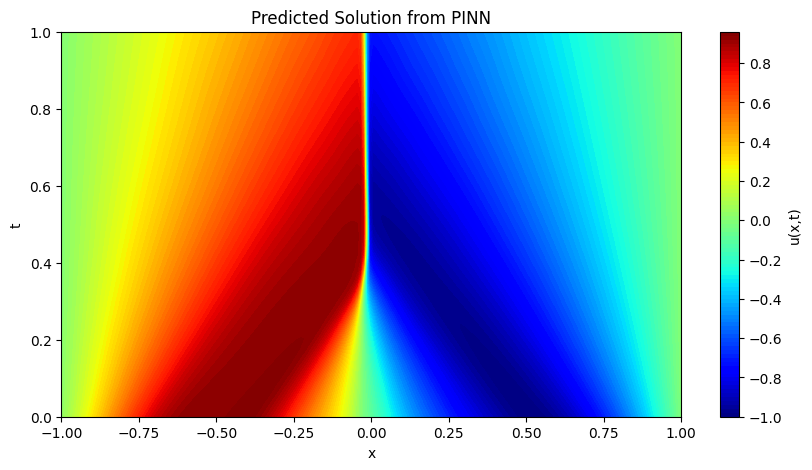

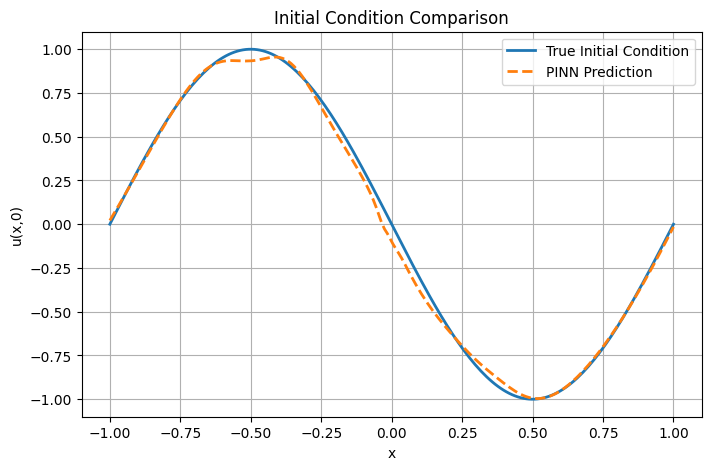

In [ ]:
# Generate data
data = generate_training_data(
    N_initial_condition=100,
    N_boundary_condition=100,
    N_f=5000,
    device=device
)

# Define architecture
layers = [2, 64, 64, 64, 64, 1]

# Baseline model
model = PINNSolver(
    layers=layers,
    nu=nu,
    device=device,
    adaptive_weights=False,
    lambda_ic=1.0,
    lambda_bc=1.0,
    lambda_pde=1.0
)

# Train
history = model.fit(data, epochs=5000, lr=1e-3, print_every=200)

# Plots
model.plot_loss_history(history)
model.plot_solution()
model.plot_initial_condition_comparison()

## *Manual PINN*

Epoch     0 | Total: 0.610328 | IC: 0.569507 | BC: 0.035116 | PDE: 0.001141
Epoch   200 | Total: 0.222782 | IC: 0.170969 | BC: 0.006605 | PDE: 0.009042
Epoch   400 | Total: 0.155885 | IC: 0.125869 | BC: 0.002556 | PDE: 0.005492
Epoch   600 | Total: 0.128396 | IC: 0.103795 | BC: 0.002050 | PDE: 0.004510
Epoch   800 | Total: 0.114501 | IC: 0.097396 | BC: 0.000616 | PDE: 0.003298
Epoch  1000 | Total: 0.107923 | IC: 0.094023 | BC: 0.000286 | PDE: 0.002723
Epoch  1200 | Total: 0.101911 | IC: 0.087934 | BC: 0.000289 | PDE: 0.002738
Epoch  1400 | Total: 0.097804 | IC: 0.083457 | BC: 0.000405 | PDE: 0.002788
Epoch  1600 | Total: 0.092808 | IC: 0.079853 | BC: 0.000175 | PDE: 0.002556
Epoch  1800 | Total: 0.086362 | IC: 0.073938 | BC: 0.000147 | PDE: 0.002455
Epoch  2000 | Total: 0.080544 | IC: 0.065716 | BC: 0.000189 | PDE: 0.002928
Epoch  2200 | Total: 0.070400 | IC: 0.059569 | BC: 0.000094 | PDE: 0.002148
Epoch  2400 | Total: 0.062122 | IC: 0.051645 | BC: 0.000097 | PDE: 0.002076
Epoch  2600 

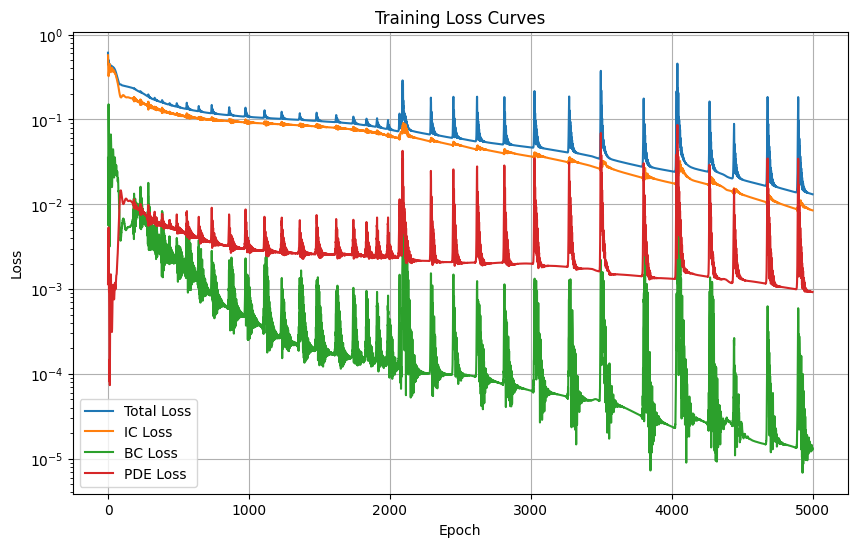

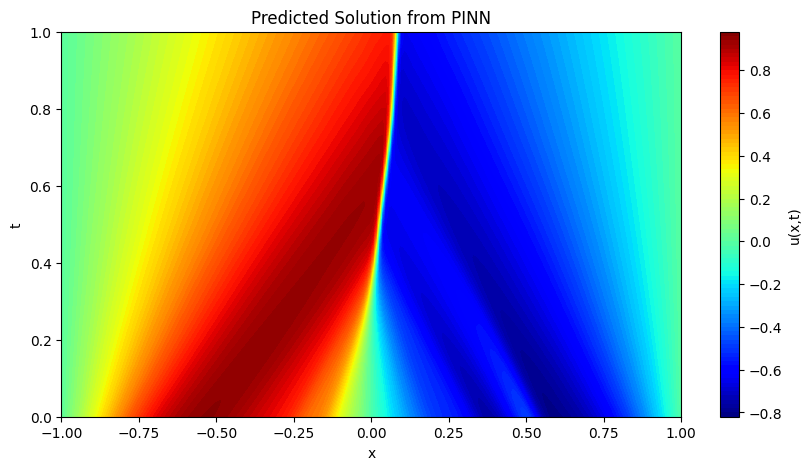

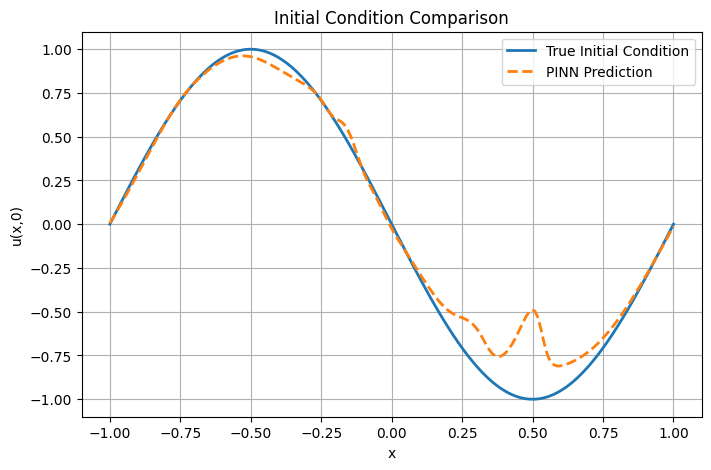

In [ ]:
data = generate_training_data(
    N_initial_condition=100,
    N_boundary_condition=100,
    N_f=5000,
    device=device
)

layers = [2, 64, 64, 64, 64, 1]

model = PINNSolver(
    layers=layers,
    nu=nu,
    device=device,
    adaptive_weights=False,
    lambda_ic=1.0,
    lambda_bc=1.0,
    lambda_pde=5.0
)

history = model.fit(data, epochs=5000, lr=1e-3, print_every=200)

model.plot_loss_history(history)
model.plot_solution()
model.plot_initial_condition_comparison()

Epoch     0 | Total: 0.446708 | IC: 0.380727 | BC: 0.055404 | PDE: 0.010578 | λ_ic: 1.0010 | λ_bc: 1.0010 | λ_pde: 1.0010
Epoch   200 | Total: -0.438816 | IC: 0.081641 | BC: 0.005643 | PDE: 0.057108 | λ_ic: 1.2459 | λ_bc: 1.2250 | λ_pde: 1.2179
Epoch   400 | Total: -1.053960 | IC: 0.055276 | BC: 0.006566 | PDE: 0.050996 | λ_ic: 1.5356 | λ_bc: 1.4973 | λ_pde: 1.4838
Epoch   600 | Total: -1.656373 | IC: 0.051403 | BC: 0.001779 | PDE: 0.039583 | λ_ic: 1.8845 | λ_bc: 1.8302 | λ_pde: 1.8092
Epoch   800 | Total: -2.271203 | IC: 0.040735 | BC: 0.000483 | PDE: 0.029462 | λ_ic: 2.3091 | λ_bc: 2.2376 | λ_pde: 2.2077
Epoch  1000 | Total: -2.897241 | IC: 0.027441 | BC: 0.000304 | PDE: 0.021886 | λ_ic: 2.8288 | λ_bc: 2.7350 | λ_pde: 2.6957
Epoch  1200 | Total: -3.517808 | IC: 0.018204 | BC: 0.000174 | PDE: 0.018352 | λ_ic: 3.4777 | λ_bc: 3.3432 | λ_pde: 3.2927
Epoch  1400 | Total: -4.158480 | IC: 0.010419 | BC: 0.000163 | PDE: 0.011819 | λ_ic: 4.2820 | λ_bc: 4.0859 | λ_pde: 4.0242
Epoch  1600 | Tot

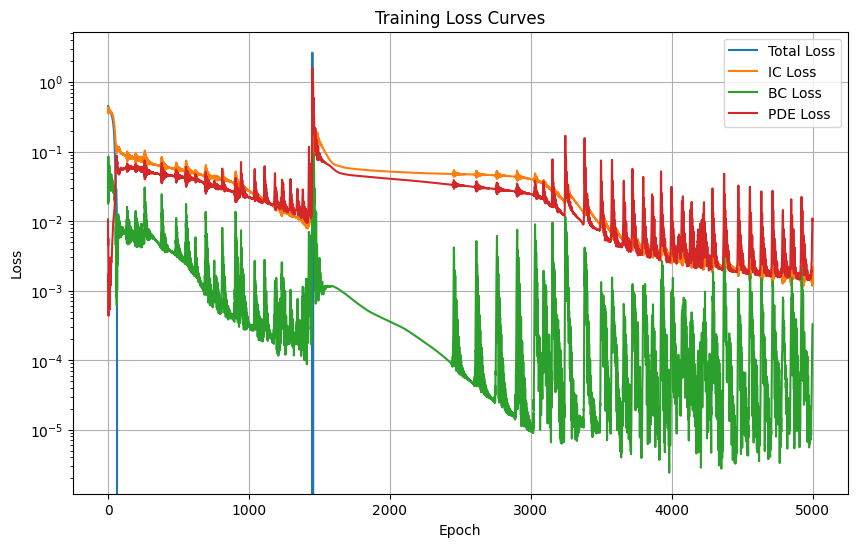

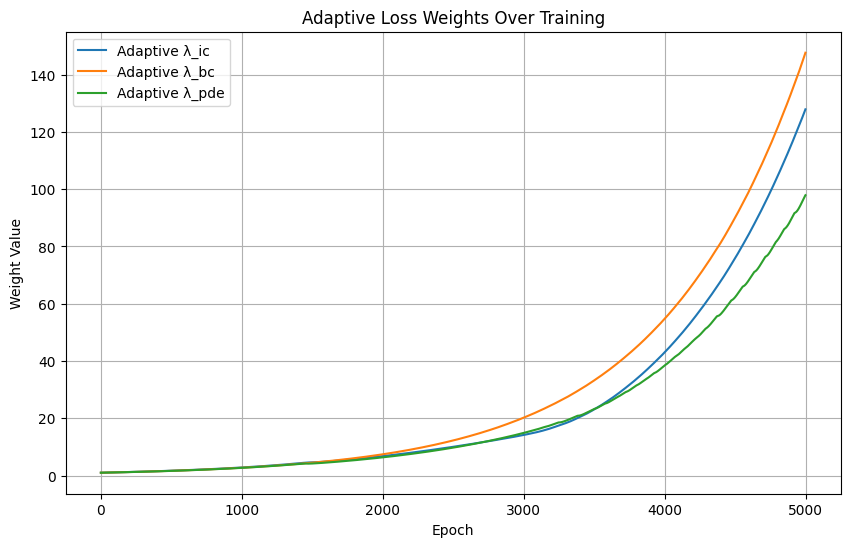

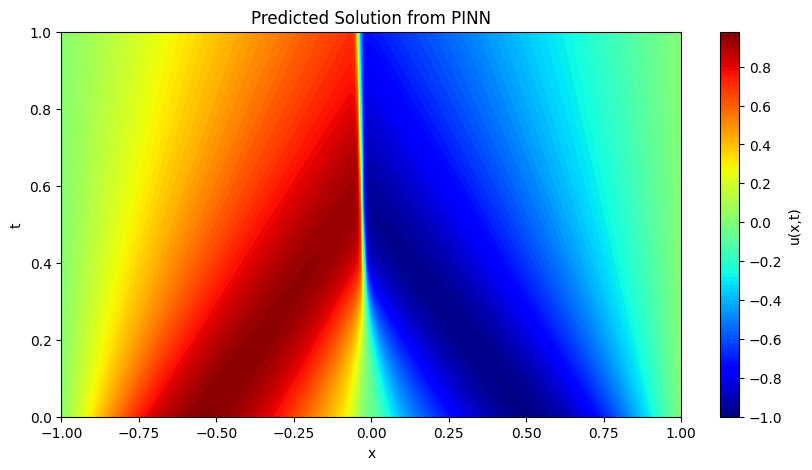

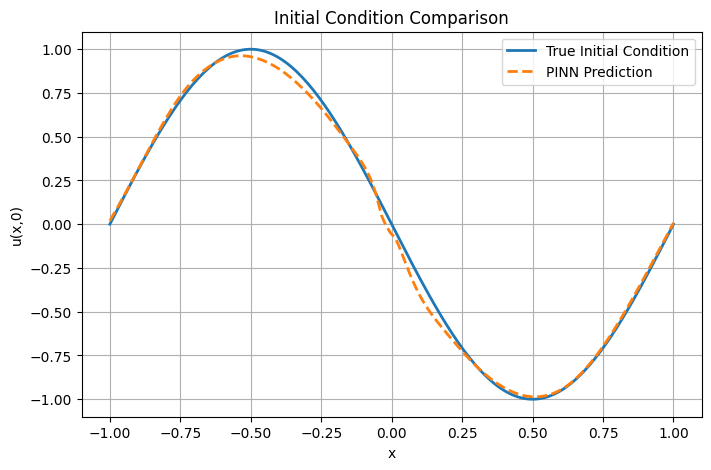

In [ ]:
data = generate_training_data(
    N_initial_condition=100,
    N_boundary_condition=100,
    N_f=5000,
    device=device
)

layers = [2, 64, 64, 64, 64, 1]

model = PINNSolver(
    layers=layers,
    nu=nu,
    device=device,
    adaptive_weights=True
)

history = model.fit(data, epochs=5000, lr=1e-3, print_every=200)

model.plot_loss_history(history)
model.plot_adaptive_weights(history)
model.plot_solution()
model.plot_initial_condition_comparison()

In [ ]:
import pandas as pd


results = [
    {"Model": "Baseline PINN", "IC Error": 0.001245, "BC Error": 0.000017, "PDE Error": 0.001425},
    {"Model": "Manual Weighted PINN", "IC Error": 0.005589, "BC Error": 0.000014, "PDE Error": 0.000644},
    {"Model": "Adaptive PINN", "IC Error": 0.000336, "BC Error":  0.000006, "PDE Error": 0.000765},
]

df = pd.DataFrame(results)

# Lower error = better
df["Average Error"] = df[["IC Error", "BC Error", "PDE Error"]].mean(axis=1)
df = df.sort_values("Average Error").reset_index(drop=True)
df["Rank"] = df.index + 1

print("=== Ranked Comparison of PINN Variants ===")
print(df)

try:
    display(df.style.highlight_min(subset=["IC Error", "BC Error", "PDE Error", "Average Error"], axis=0))
except:
    pass

=== Ranked Comparison of PINN Variants ===
                  Model  IC Error  BC Error  PDE Error  Average Error  Rank
0         Adaptive PINN  0.000336  0.000006   0.000765       0.000369     1
1         Baseline PINN  0.001245  0.000017   0.001425       0.000896     2
2  Manual Weighted PINN  0.005589  0.000014   0.000644       0.002082     3


,Model,IC Error,BC Error,PDE Error,Average Error,Rank
0,Adaptive PINN,0.000336,0.000006,0.000765,0.000369,1
1,Baseline PINN,0.001245,0.000017,0.001425,0.000896,2
2,Manual Weighted PINN,0.005589,0.000014,0.000644,0.002082,3
